In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/IMDB Dataset.csv")



# EDA for text (Explore entry Data Analises)


In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [8]:
df["review_length"] = df["review"].apply(len)
df["review_length"].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


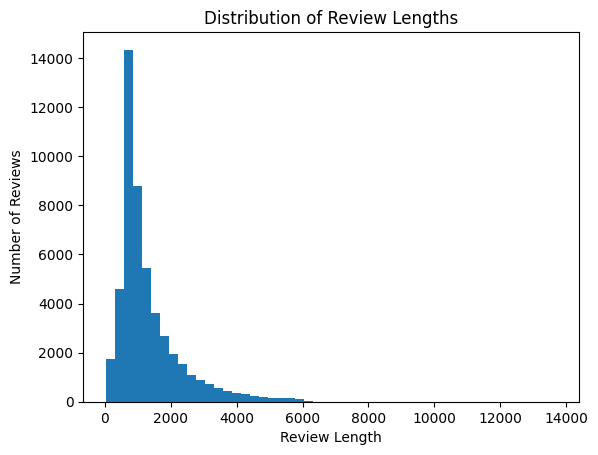

In [9]:
import matplotlib.pyplot as plt

plt.hist(df['review_length'], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Lengths")
plt.show()

# Text Procesing

In [10]:
df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

In [11]:
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


In [12]:
from sklearn.model_selection import train_test_split

x = df["review"]
y = df["sentiment"]


x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [13]:
# Text Vectorization b/c input reviews is non-numeric
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer =TfidfVectorizer(
    stop_words ='english',
    max_features=5000
)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [14]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_tfidf,y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred_log = log_model.predict(x_test_tfidf)

In [16]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test,y_pred_log)

print("Logistic Regression Accuracy: ", lr_accuracy)

Logistic Regression Accuracy:  0.8889


In [17]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



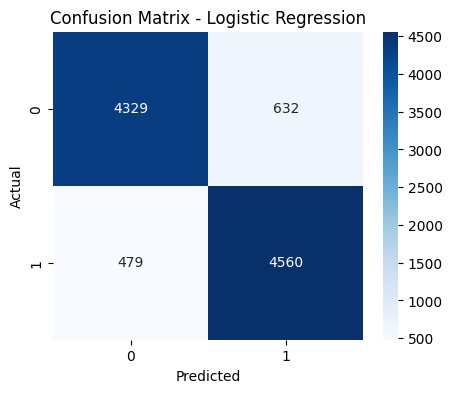

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [19]:
import joblib

joblib.dump(log_model,"/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/logistic_regression_imdb_model.pkl")
joblib.dump(vectorizer, "/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/tfidf_vectorizer.pkl")

['/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/tfidf_vectorizer.pkl']

In [20]:
loaded_model = joblib.load("/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/logistic_regression_imdb_model.pkl")
loaded_vectorizer = joblib.load("/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/tfidf_vectorizer.pkl")

review = ["This movie was not good "]

review_vec = loaded_vectorizer.transform(review)
prediction = loaded_model.predict(review_vec)

print("Sentiment:",
      "Positive" if prediction[0] == 1 else "Negative")

Sentiment: Positive


# Apply Naive Bayyes Model

In [21]:
from sklearn.naive_bayes import MultinomialNB



In [22]:
# Initialize Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(x_train_tfidf, y_train)

MultinomialNB()

In [23]:
# Predict on test data
y_pred_nb = nb_model.predict(x_test_tfidf)

In [24]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", nb_accuracy)


Naive Bayes Accuracy: 0.8508


In [25]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



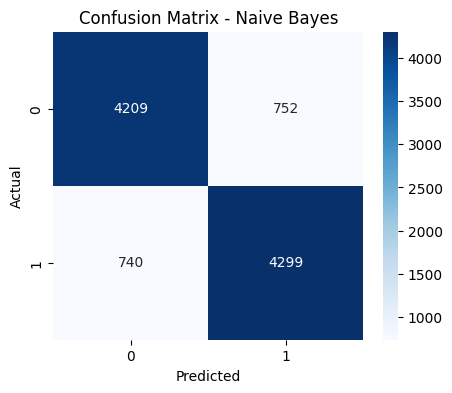

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [27]:
joblib.dump(nb_model, "/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/naive_bayes_imdb_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/naive_bayes_imdb_model.pkl']

# Apply Decision Trees Model

In [28]:
from sklearn.tree import DecisionTreeClassifier


In [29]:
# Initialise Decision Trees Model
dt_model = DecisionTreeClassifier()

# Train Decision Trees Model
dt_model.fit(x_train_tfidf,y_train)

DecisionTreeClassifier()

In [30]:
y_pred_dt = dt_model.predict(x_test_tfidf)

In [31]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy :",dt_accuracy)

Decision Tree Accuracy : 0.725


In [32]:
from sklearn.metrics import classification_report

print("Decision Trees Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Trees Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.73      0.72      4961
           1       0.73      0.72      0.73      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.72      0.73     10000



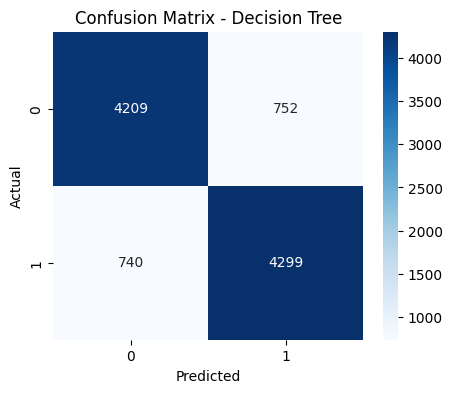

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [34]:
joblib.dump(dt_model,"/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/decision_tree_imdb_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/decision_tree_imdb_model.pkl']

# Apply Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestClassifier



In [36]:
# Initialise Random Forest Model
rf_model = RandomForestClassifier()

# Train Decision Trees Model
rf_model.fit(x_train_tfidf,y_train)

RandomForestClassifier()

In [37]:
y_pred_rf = dt_model.predict(x_test_tfidf)

In [38]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy :",rf_accuracy)

Random Forest Accuracy : 0.725


In [39]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.73      0.72      4961
           1       0.73      0.72      0.73      5039

    accuracy                           0.72     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.72      0.73     10000



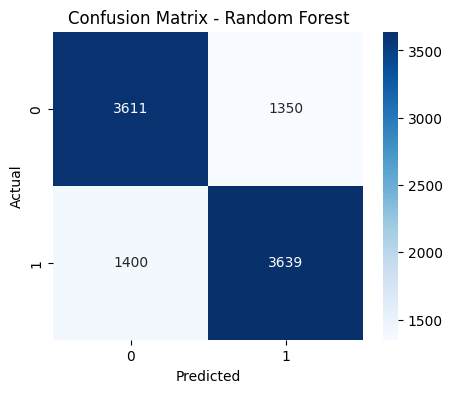

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [41]:
joblib.dump(dt_model,"/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/random_forest_imdb_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Python_lerning_SaylaiMIT/Ai_Task/Classification/Movies Review (Binary)/random_forest_imdb_model.pkl']

In [42]:
comparison = pd.DataFrame({
    "Model" : ["Logistic Regression", "Naive Bayes","Decision Tree", "Random Forest"],
    "Accuracy": [lr_accuracy, nb_accuracy,dt_accuracy, rf_accuracy]
})